In [28]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.shape

(167, 10)

In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [5]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [6]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [8]:
X = df.drop('country', axis = 1)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 6, random_state = 42)
X_c = pca.fit_transform(X_scaled)

In [22]:
print("Total variance :", sum(pca.explained_variance_ratio_))

TOtal variance : 0.9701523224082288


In [59]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,10):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_c)
    wcss.append(km.inertia_)
print("Inertia values: ", wcss)

Inertia values:  [1458.138940579566, 1019.1596234669029, 786.8230037289762, 655.9841844982512, 587.3093330681986, 537.1746162942943, 484.6781400792206, 431.21873139514753, 402.9169900557798]


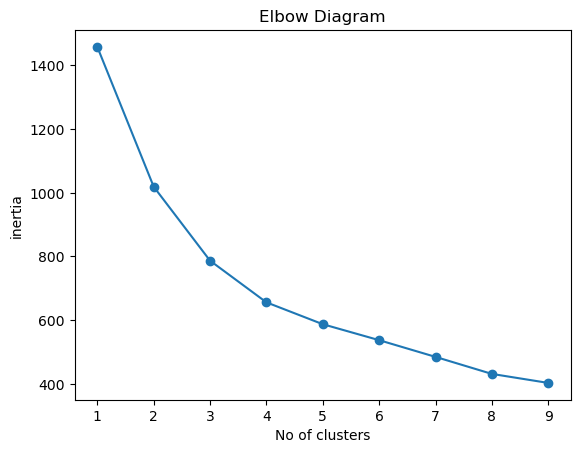

In [77]:
import matplotlib.pyplot as plt
plt.plot(range(1,10), wcss, marker = 'o')
plt.title('Elbow Diagram')
plt.xlabel('No of clusters')
plt.ylabel('inertia')
plt.show()

In [78]:
km = KMeans(n_clusters = 3, random_state = 42)
km.fit(X_c)
labels = km.labels_
df['km_clusters'] = labels
print(df['km_clusters'].value_counts())

km_clusters
0    86
2    45
1    36
Name: count, dtype: int64


In [79]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
X_c1 = tsne.fit_transform(X_scaled)
print('TSNE Reduced shape : ', X_c1.shape)

TSNE Reduced shape :  (167, 2)


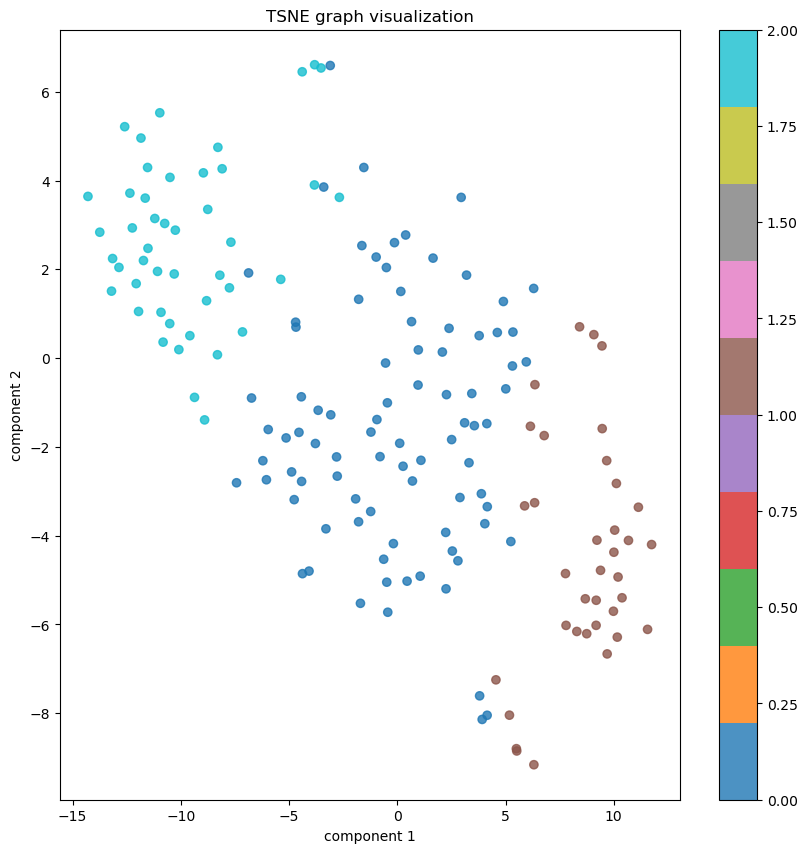

In [80]:
plt.figure(figsize = (10,10))
scat = plt.scatter(X_c1[:,0], X_c1[:,1], c = labels, cmap = 'tab10', alpha = 0.8)
plt.title('TSNE graph visualization')
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar(scat)
plt.show()

In [81]:
df.groupby('km_clusters')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()

,child_mort,income,gdpp,life_expec
km_clusters,,,,
0,22.456977,12321.744186,6461.767442,72.566279
1,5.000000,45672.222222,42494.444444,80.127778
2,95.106667,3539.844444,1766.711111,59.055556


In [82]:
print(df[df['km_clusters'] == 0][['country']].values)

[['Albania']
 ['Algeria']
 ['Antigua and Barbuda']
 ['Argentina']
 ['Armenia']
 ['Azerbaijan']
 ['Bahamas']
 ['Bangladesh']
 ['Barbados']
 ['Belarus']
 ['Belize']
 ['Bhutan']
 ['Bolivia']
 ['Bosnia and Herzegovina']
 ['Botswana']
 ['Brazil']
 ['Bulgaria']
 ['Cambodia']
 ['Cape Verde']
 ['Chile']
 ['China']
 ['Colombia']
 ['Costa Rica']
 ['Croatia']
 ['Dominican Republic']
 ['Ecuador']
 ['Egypt']
 ['El Salvador']
 ['Estonia']
 ['Fiji']
 ['Georgia']
 ['Grenada']
 ['Guatemala']
 ['Guyana']
 ['Hungary']
 ['India']
 ['Indonesia']
 ['Iran']
 ['Iraq']
 ['Jamaica']
 ['Jordan']
 ['Kazakhstan']
 ['Kyrgyz Republic']
 ['Latvia']
 ['Lebanon']
 ['Libya']
 ['Lithuania']
 ['Macedonia, FYR']
 ['Malaysia']
 ['Maldives']
 ['Mauritius']
 ['Micronesia, Fed. Sts.']
 ['Moldova']
 ['Mongolia']
 ['Montenegro']
 ['Morocco']
 ['Myanmar']
 ['Nepal']
 ['Oman']
 ['Panama']
 ['Paraguay']
 ['Peru']
 ['Philippines']
 ['Poland']
 ['Romania']
 ['Russia']
 ['Samoa']
 ['Saudi Arabia']
 ['Serbia']
 ['Seychelles']
 ['Solomo

In [83]:
print(df[df['km_clusters'] == 1][['country']].values)

[['Australia']
 ['Austria']
 ['Bahrain']
 ['Belgium']
 ['Brunei']
 ['Canada']
 ['Cyprus']
 ['Czech Republic']
 ['Denmark']
 ['Finland']
 ['France']
 ['Germany']
 ['Greece']
 ['Iceland']
 ['Ireland']
 ['Israel']
 ['Italy']
 ['Japan']
 ['Kuwait']
 ['Luxembourg']
 ['Malta']
 ['Netherlands']
 ['New Zealand']
 ['Norway']
 ['Portugal']
 ['Qatar']
 ['Singapore']
 ['Slovak Republic']
 ['Slovenia']
 ['South Korea']
 ['Spain']
 ['Sweden']
 ['Switzerland']
 ['United Arab Emirates']
 ['United Kingdom']
 ['United States']]


In [84]:
print(df[df['km_clusters'] == 2][['country']].values)

[['Afghanistan']
 ['Angola']
 ['Benin']
 ['Burkina Faso']
 ['Burundi']
 ['Cameroon']
 ['Central African Republic']
 ['Chad']
 ['Comoros']
 ['Congo, Dem. Rep.']
 ['Congo, Rep.']
 ["Cote d'Ivoire"]
 ['Equatorial Guinea']
 ['Eritrea']
 ['Gabon']
 ['Gambia']
 ['Ghana']
 ['Guinea']
 ['Guinea-Bissau']
 ['Haiti']
 ['Kenya']
 ['Kiribati']
 ['Lao']
 ['Lesotho']
 ['Liberia']
 ['Madagascar']
 ['Malawi']
 ['Mali']
 ['Mauritania']
 ['Mozambique']
 ['Namibia']
 ['Niger']
 ['Nigeria']
 ['Pakistan']
 ['Rwanda']
 ['Senegal']
 ['Sierra Leone']
 ['South Africa']
 ['Sudan']
 ['Tanzania']
 ['Timor-Leste']
 ['Togo']
 ['Uganda']
 ['Yemen']
 ['Zambia']]


In [85]:
print('Cluster 2 countries -> Underdeveloped → Needs aid most')
print('Cluster 0 countries -> Developing')
print('Cluster 1 countries -> Developed')

Cluster 2 countries -> Underdeveloped → Needs aid most
Cluster 0 countries -> Developing
Cluster 1 countries -> Developed
